### “E-commerce Fashion Analytics: Customer Trends & Product Performance Analysis (Myntra Dataset)”

Business Problem Statement -

As a data analyst, your goal is to analyze Myntra product data to:
Identify top-performing categories & brands
Understand pricing strategies
Detect discount patterns
Analyze customer ratings behavior
Provide actionable insights to increase revenue

Key Skills Covered -
✔ Data Cleaning

✔ Exploratory Data Analysis (EDA)

✔ GroupBy & Aggregations

✔ Feature Engineering

✔ Data Visualization (Matplotlib + Seaborn)

✔ Business Insights

✔ SQL Thinking using Pandas

### Step 1: Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [7]:
df =pd.read_csv("../data/myntra_dataset_ByScraping.csv")

#pd.read_csv("..\\data\\myntra_dataset_ByScraping.csv")

### Step 2: Load Dataset

In [18]:
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
Index: 35073 entries, 0 to 52018
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   brand_name         35073 non-null  str     
 1   pants_description  35073 non-null  str     
 2   price              35073 non-null  float64 
 3   MRP                35073 non-null  float64 
 4   discount_percent   35073 non-null  float64 
 5   ratings            35073 non-null  float64 
 6   number_of_ratings  35073 non-null  float64 
 7   DiscountPercent    35073 non-null  float64 
 8   PriceCategory      34922 non-null  category
dtypes: category(1), float64(6), str(2)
memory usage: 2.4 MB


,price,MRP,discount_percent,ratings,number_of_ratings,DiscountPercent
count,35073.000000,35073.000000,35073.000000,35073.000000,35073.000000,35073.000000
mean,1618.151627,3277.913654,2.039860,3.975617,103.707296,51.661432
std,1758.242730,2572.046817,5.446518,0.453471,520.459162,15.956345
min,337.000000,499.000000,0.020000,1.000000,5.000000,2.000000
25%,899.000000,2399.000000,0.400000,3.800000,14.000000,40.010000
50%,1418.000000,2999.000000,0.550000,4.000000,31.000000,54.680000
75%,1829.000000,3699.000000,0.650000,4.200000,75.000000,63.900000
max,54000.000000,72000.000000,64.000000,5.000000,30700.000000,86.140000


In [19]:
df.columns

Index(['brand_name', 'pants_description', 'price', 'MRP', 'discount_percent',
       'ratings', 'number_of_ratings', 'DiscountPercent', 'PriceCategory'],
      dtype='str')

### Step 3: Data Cleaning

In [11]:
# Check missing values
print(df.isnull().sum())

# Convert numeric columns
numeric_columns = ["price", "MRP", "discount_percent", "ratings", "number_of_ratings"]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")

# Remove duplicates and missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

df.info()

brand_name           0
pants_description    0
price                0
MRP                  0
discount_percent     0
ratings              0
number_of_ratings    0
dtype: int64
<class 'pandas.DataFrame'>
Index: 35073 entries, 0 to 52018
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand_name         35073 non-null  str    
 1   pants_description  35073 non-null  str    
 2   price              35073 non-null  float64
 3   MRP                35073 non-null  float64
 4   discount_percent   35073 non-null  float64
 5   ratings            35073 non-null  float64
 6   number_of_ratings  35073 non-null  float64
dtypes: float64(5), str(2)
memory usage: 2.1 MB


### Step 4: Feature Engineering

In [13]:
# Create discount percentage from MRP and selling price
df['DiscountPercent'] = ((df['MRP'] - df['price']) / df['MRP']) * 100
df['DiscountPercent'] = df['DiscountPercent'].round(2)

# Create price category from selling price
df['PriceCategory'] = pd.cut(
    df['price'],
    bins=[0, 500, 1500, 3000, 10000],
    labels=['Low', 'Medium', 'High', 'Premium']
 )

df[['price', 'MRP', 'DiscountPercent', 'PriceCategory']].head()

,price,MRP,DiscountPercent,PriceCategory
0,1374.0,2499.0,45.02,Medium
1,1829.0,2999.0,39.01,High
2,974.0,2499.0,61.02,Medium
3,873.0,2299.0,62.03,Medium
4,1478.0,2899.0,49.02,Medium


Scenario 1: Top Performing Brands

Business Question: Which brands generate the most product listings

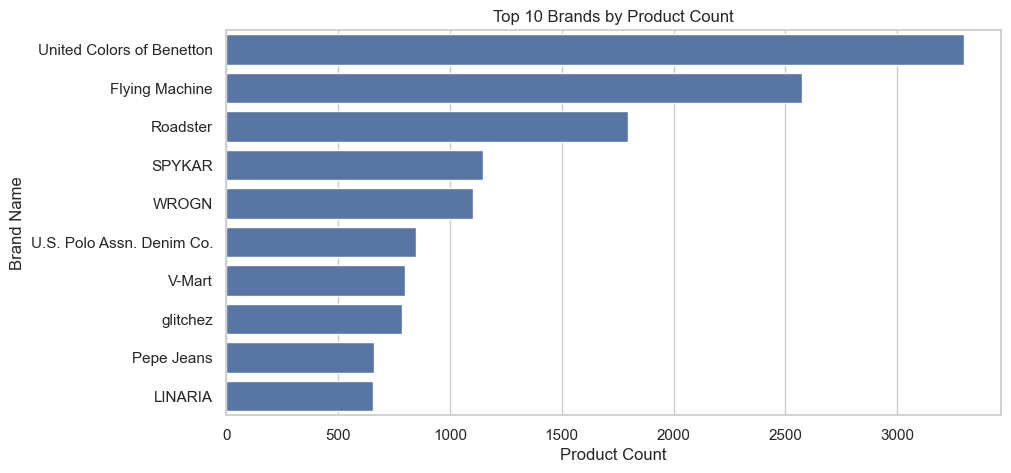

In [16]:
brand_count = df['brand_name'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=brand_count.values, y=brand_count.index)
plt.title('Top 10 Brands by Product Count')
plt.xlabel('Product Count')
plt.ylabel('Brand Name')
plt.show()

Insights - 
1. The marketplace appears to be dominated by a few brands, especially United Colors of Benetton and Flying Machine.
2. The sharp decline after the top brands suggests brand concentration, meaning a few brands likely control a large share of the category.
3. Smaller brands may need better assortment expansion, pricing strategy, or promotions to compete with the leaders.

Scenario 2: Category-wise Revenue Potential

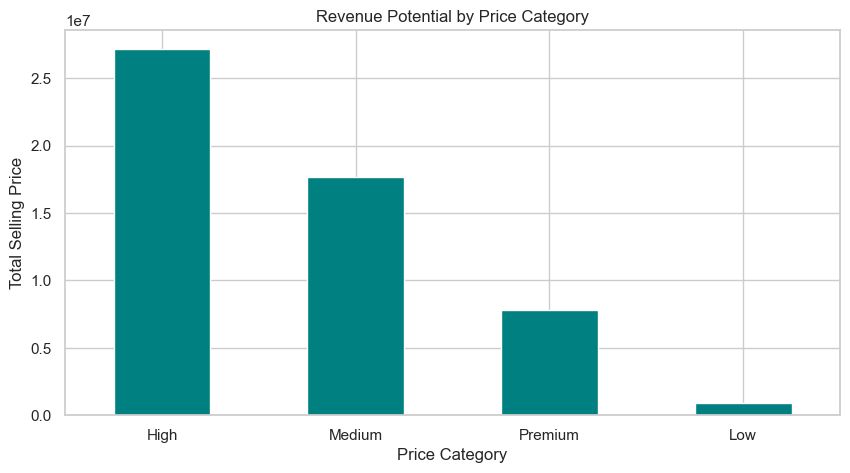

In [22]:
category_price = df.groupby('PriceCategory', observed=False)['price'].sum().sort_values(ascending=False)

category_price.plot(kind='bar', figsize=(10, 5), color='teal')
plt.title('Revenue Potential by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Total Selling Price')
plt.xticks(rotation=0)
plt.show()

Insights -
1. The High price segment contributes the highest total selling value, making it the strongest revenue-driving segment in the dataset.
2. Medium-priced products are the second-largest contributor, which suggests this segment has both strong volume and strong monetization potential.
3. Premium products contribute less than High and Medium categories, indicating that higher ticket size alone does not guarantee the highest overall revenue contribution.
4. Low-priced products contribute the least total selling value, which may be due to lower prices, fewer listings, or both.
5. From a business perspective, the High and Medium price bands appear to offer the best balance between assortment depth and revenue potential.

In [23]:
df.columns

Index(['brand_name', 'pants_description', 'price', 'MRP', 'discount_percent',
       'ratings', 'number_of_ratings', 'DiscountPercent', 'PriceCategory'],
      dtype='str')

Scenario 3: Discount Strategy Analysis

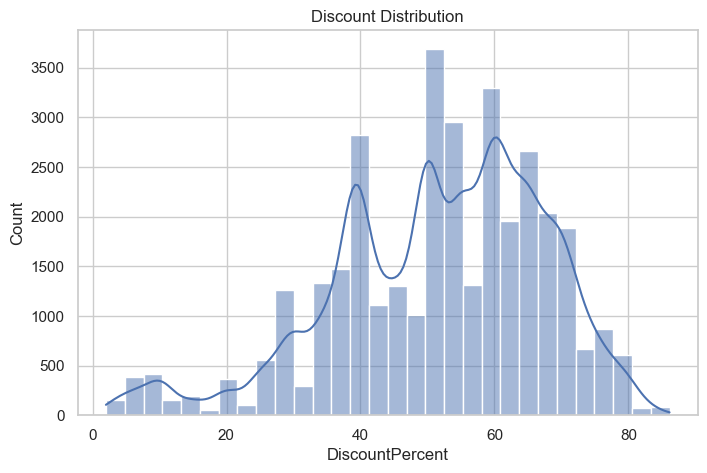

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['DiscountPercent'], bins=30, kde=True)
plt.title("Discount Distribution")
plt.show()

Insights - 
Discount strategy analysis showed that the majority of products were concentrated in the 40% to 70% discount band, with the strongest clustering around 50% to 65%, indicating that medium-to-high promotional discounting is a dominant pricing strategy on the platform.

Scenario 4: Price vs Rating Relationship

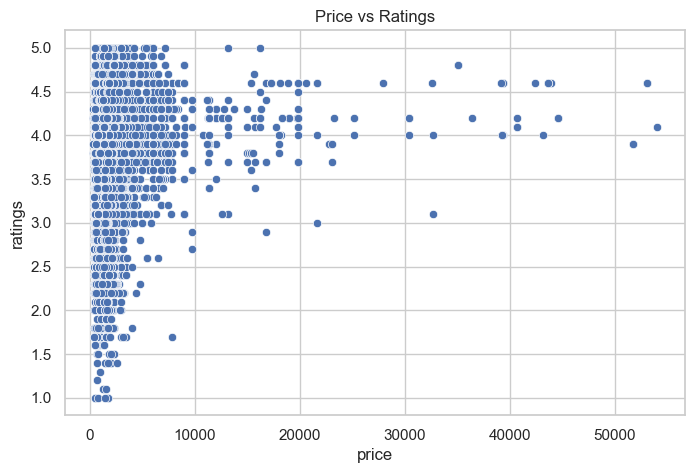

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='price', y='ratings', data=df)
plt.title("Price vs Ratings")
plt.show()

Insights - 
1. Price vs rating analysis showed a weak correlation between product price and customer ratings, indicating that higher-priced products do not necessarily receive better reviews. Most products across price bands were rated between 3.5 and 4.8, suggesting that customer satisfaction is influenced by factors beyond price alone.
2. There is no strong linear relationship between price and ratings.
Most products, whether low-priced or expensive, are clustered between ratings of about 3.5 and 4.8. This suggests higher price does not automatically lead to higher customer ratings.
3. Lower-priced products are much more densely populated.
The left side of the plot has a heavy concentration of points, which means the dataset contains many more low-to-mid-priced products than very expensive ones.
4. High ratings are present across many price ranges.
Products with ratings above 4.0 appear in both low-price and high-price ranges. This indicates that customer satisfaction is not limited to premium-priced items.
5. Very expensive products are fewer, but still mostly well rated.
At higher price points, the number of products drops sharply, but many of those products still lie around 4.0 to 4.6 ratings. This may suggest premium products maintain reasonably good perceived quality.
6. Low-rated products are mostly concentrated in the lower price range.
Products with ratings closer to 1.0 to 2.5 appear mostly among cheaper items. That can indicate inconsistent quality in the lower-price segment.
7. Ratings seem more stable than prices.
Price varies a lot, from near zero to above 50,000, but ratings stay in a relatively narrow band from about 1 to 5. This is common in customer review datasets.

Scenario 5: High Discount vs Ratings

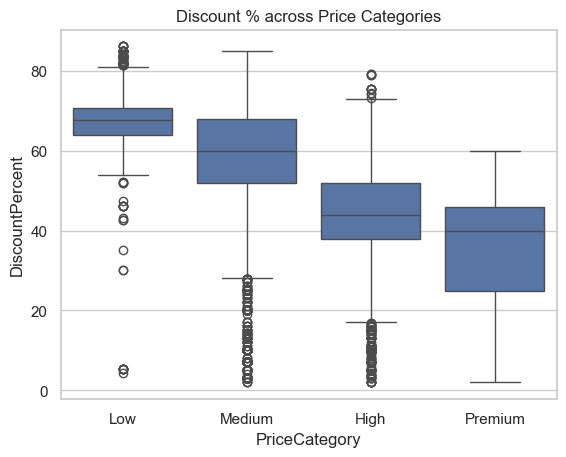

In [27]:
sns.boxplot(x='PriceCategory', y='DiscountPercent', data=df)
plt.title("Discount % across Price Categories")
plt.show()

Insights - 
1. Low-priced products receive the highest median discounts.
The Low category has the highest central discount level, around the upper 60% range. This suggests lower-priced items are heavily discounted, likely to drive volume and fast conversions.
2. Medium-priced products also follow an aggressive discount strategy.
The Medium category shows a high median discount as well, with a fairly wide spread. This indicates medium-priced items are a major promotional segment and may be used to balance sales volume with revenue.
3. High-priced products receive more moderate discounts.
The High category has a lower median discount than Low and Medium, mostly around the 40% to 50% range. This suggests brands protect margins more carefully in higher-value products.
4. Premium products have the lowest overall discount tendency.
The Premium category appears to have the lowest median discount and a broader spread. This means premium items are discounted less aggressively, likely to preserve brand positioning and perceived exclusivity.
5. Discount variability differs across categories.
Medium, High, and Premium categories show wider variation, which suggests brands may be using different discount strategies depending on product positioning, demand, and inventory.
6. There are outliers in all categories.
Some products receive unusually high or low discounts compared to their category. These outliers may represent special campaigns, clearance inventory, or premium exceptions.

Scenario 6: Top Rated Products

In [28]:
df.columns

Index(['brand_name', 'pants_description', 'price', 'MRP', 'discount_percent',
       'ratings', 'number_of_ratings', 'DiscountPercent', 'PriceCategory'],
      dtype='str')

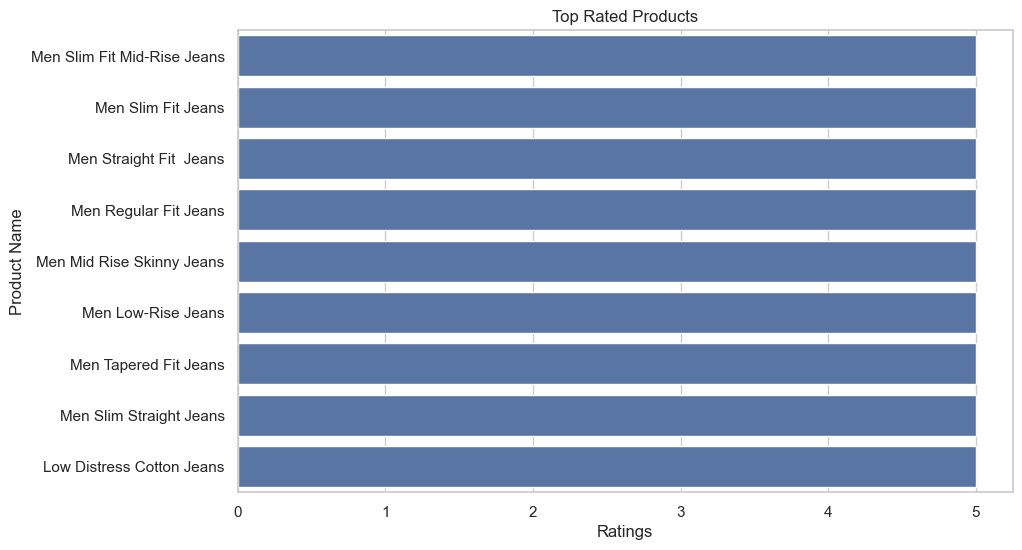

In [34]:
top_rated = df.sort_values(by='ratings', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='ratings', y='pants_description', data=top_rated)
plt.title('Top Rated Products')
plt.xlabel('Ratings')
plt.ylabel('Product Name')
plt.show()

Insights - 
1. The top-rated products are heavily concentrated around a perfect rating of 5.0.
This means the chart is showing products with excellent customer satisfaction, but it also makes it hard to distinguish which one is truly better than the others based on rating alone.
2. Most of the top-rated items are jeans-focused products.
Names like slim fit, straight fit, regular fit, tapered fit, and low-rise jeans appear repeatedly, which suggests jeans are a strong-performing product segment in terms of customer satisfaction.
3. Product fit and style seem to matter strongly in customer preference.
Many of the top-rated items are specific fit-based variants, which indicates customers may respond positively to products that clearly match style and fit expectations.
4. The chart highlights product popularity in quality perception, not necessarily sales performance.
A product can have a high rating even if only a small number of users reviewed it. So this plot is useful for identifying highly appreciated products, but not enough to judge business success by itself.
5. These products can be treated as benchmark items.
The top-rated products may represent strong product-market fit, so brands or sellers could study their design, fit, pricing, and promotion strategy to replicate that success in similar product

Scenario 7: Brand vs Average Rating (GROUPBY)

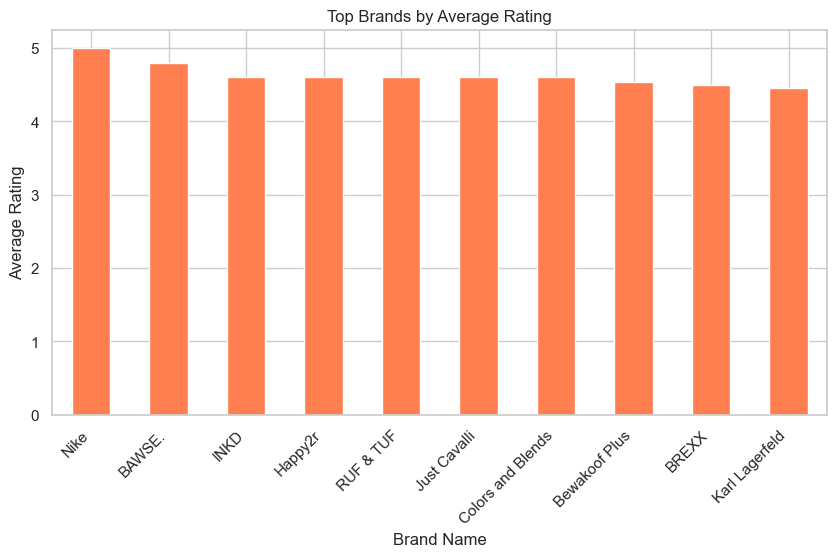

In [37]:
brand_rating = df.groupby('brand_name')['ratings'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
brand_rating.plot(kind='bar', color='coral')
plt.title('Top Brands by Average Rating')
plt.xlabel('Brand Name')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.show()

Insights - 
1. Nike has the highest average rating in this plot, close to 5.0, which suggests very strong customer satisfaction compared with the other brands shown.
2. The top 10 brands are all rated within a narrow range, roughly from 4.4 to 5.0.
This means the difference between these brands is not very large, even though the chart ranks them from highest to lowest.
3. Most leading brands have ratings above 4.5.
That indicates the overall quality perception for these brands is strong, and customers generally seem satisfied with their products.
4. The chart suggests that several premium or well-known brands maintain consistently good user feedback.
Brands like Nike, Karl Lagerfeld, and Just Cavalli appearing in the top group may reflect stronger brand trust and product quality perception.
5. The gap between the first-ranked and tenth-ranked brand is relatively small.
So while Nike is first, the chart does not show a dramatic performance gap. This means several brands are competing closely in terms of customer satisfaction.


Scenario 8: Correlation Analysis

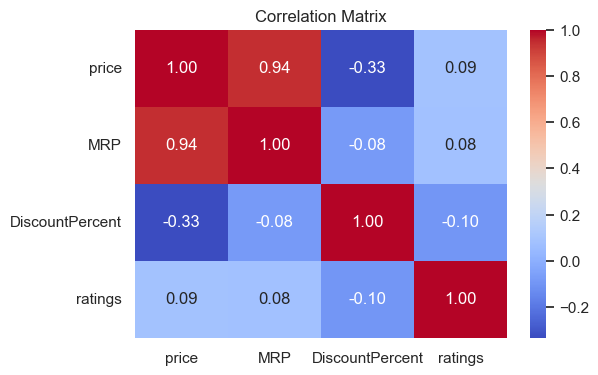

In [41]:
corr = df[['price', 'MRP', 'DiscountPercent', 'ratings']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Insights- 

1. Price and MRP have a very strong positive correlation around 0.94, which means products with higher original price also tend to have higher selling price.
2. DiscountPercent has a moderate negative relationship with price around -0.33, suggesting that higher discounts are somewhat more common on lower-priced products.
3. Ratings has very weak correlation with price, MRP, and discount percentage, which means customer ratings are not strongly driven by price or discount alone.

Scenario 9: Price Distribution

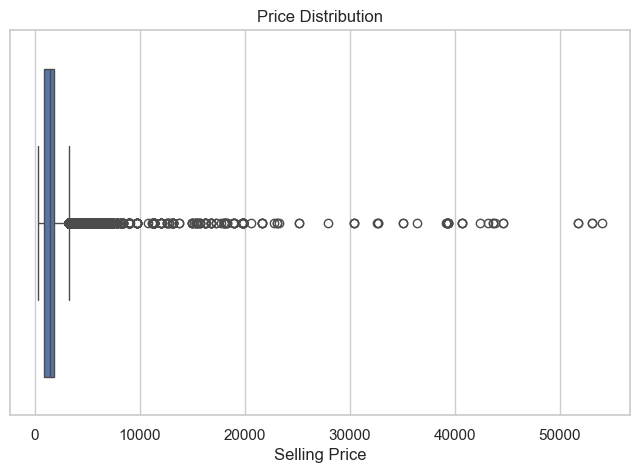

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['price'])
plt.title('Price Distribution')
plt.xlabel('Selling Price')
plt.show()

Insights - 
1. Most products are concentrated in the lower price range
2. The distribution is highly right-skewed
3. There are many high-price outliers extending far to the right
4. This means a small number of expensive products exist, but the majority of the catalog is priced much lower

Scenario 10: Category-wise Product Count

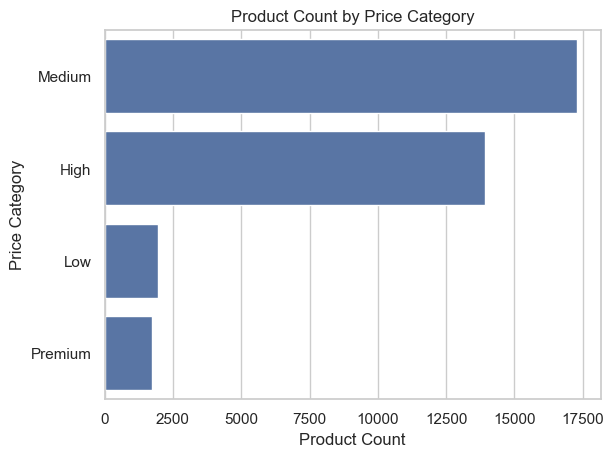

In [49]:
sns.countplot(y='PriceCategory', data=df, order=df['PriceCategory'].value_counts().index)
plt.title('Product Count by Price Category')
plt.xlabel('Product Count')
plt.ylabel('Price Category')
plt.show()

Insights - 
1. Medium has the highest product count
2. High is the second-largest category
3. Low and Premium have much smaller counts
4. This shows the catalog is concentrated in medium and high price bands, which is consistent with your earlier revenue analysis

Scenario 11: Outlier Detection

Business Question: Which numeric features contain unusual values that may affect analysis or model performance?

Method used: IQR (Interquartile Range)
- Values below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR are treated as outliers.

In [50]:
numeric_cols = ['price', 'MRP', 'DiscountPercent', 'ratings', 'number_of_ratings']

outlier_summary = []
outlier_masks = {}

for column in numeric_cols:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    outlier_masks[column] = mask

    outlier_summary.append({
        'column': column,
        'lower_bound': round(lower_bound, 2),
        'upper_bound': round(upper_bound, 2),
        'outlier_count': int(mask.sum()),
        'outlier_percentage': round(mask.mean() * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values('outlier_count', ascending=False)
outlier_summary_df

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
4,number_of_ratings,-77.50,166.50,3428,9.77
3,ratings,3.20,4.80,2335,6.66
1,MRP,449.00,5649.00,1720,4.90
0,price,-496.00,3224.00,1618,4.61
2,DiscountPercent,4.17,99.74,151,0.43


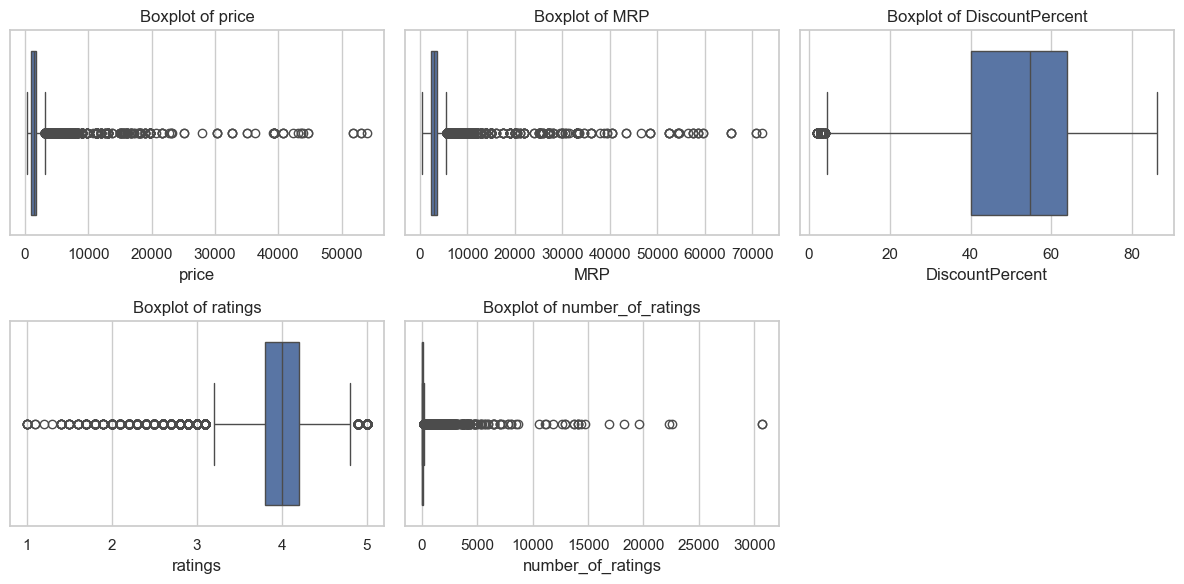

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,DiscountPercent,PriceCategory
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0,61.02,Medium
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0,62.03,Medium
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0,49.02,Medium
6,Urbano Fashion,Men Relaxed Fit Jeans,944.0,2099.0,0.55,4.0,4200.0,55.03,Medium
9,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.1,5200.0,62.03,Medium


In [51]:
plt.figure(figsize=(12, 6))
for index, column in enumerate(numeric_cols, start=1):
    plt.subplot(2, 3, index)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

outlier_rows = df[outlier_masks['price'] | outlier_masks['MRP'] | outlier_masks['DiscountPercent'] | outlier_masks['ratings'] | outlier_masks['number_of_ratings']]
outlier_rows.head()

Scenario 12: Univariate Analysis

Business Question: What does the distribution of each important variable look like when analyzed independently?

Coverage:
- Summary statistics
- Numeric feature distributions
- Boxplots for spread and skewness
- Categorical frequency analysis

In [52]:
univariate_numeric_cols = ['price', 'MRP', 'DiscountPercent', 'ratings', 'number_of_ratings']

df[univariate_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,35073.0,1618.151627,1758.242730,337.0,899.00,1418.00,1829.0,54000.00
MRP,35073.0,3277.913654,2572.046817,499.0,2399.00,2999.00,3699.0,72000.00
DiscountPercent,35073.0,51.661432,15.956345,2.0,40.01,54.68,63.9,86.14
ratings,35073.0,3.975617,0.453471,1.0,3.80,4.00,4.2,5.00
number_of_ratings,35073.0,103.707296,520.459162,5.0,14.00,31.00,75.0,30700.00


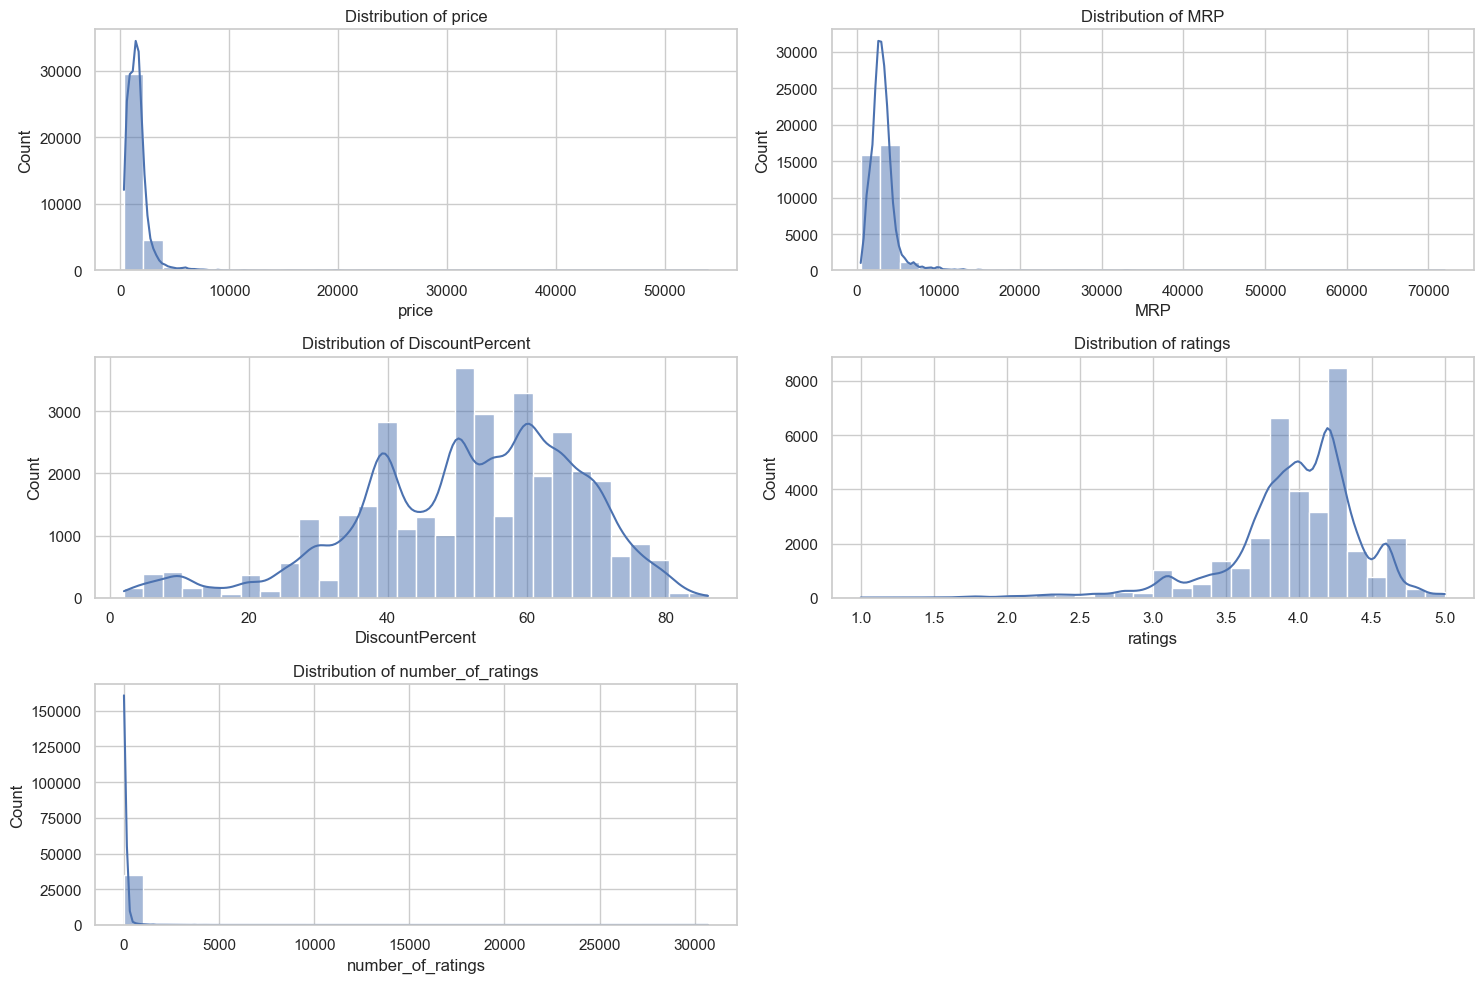

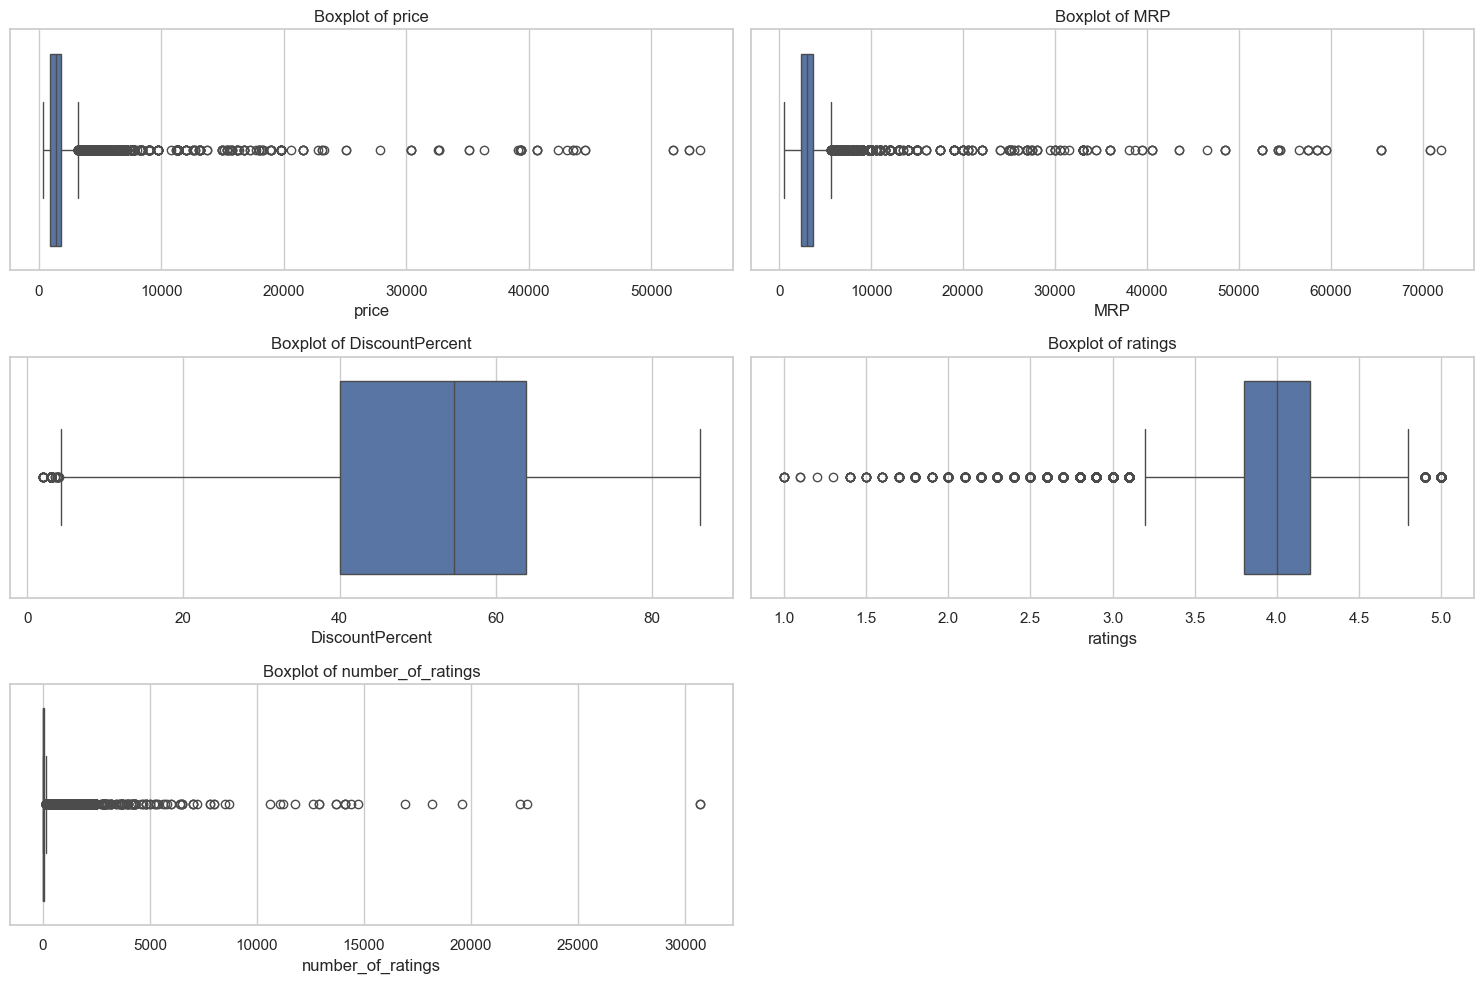

In [53]:
plt.figure(figsize=(15, 10))
for index, column in enumerate(univariate_numeric_cols, start=1):
    plt.subplot(3, 2, index)
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for index, column in enumerate(univariate_numeric_cols, start=1):
    plt.subplot(3, 2, index)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

PriceCategory
Medium     17296
High       13931
Low         1961
Premium     1734
Name: count, dtype: int64
brand_name
United Colors of Benetton    3300
Flying Machine               2576
Roadster                     1796
SPYKAR                       1149
WROGN                        1101
U.S. Polo Assn. Denim Co.     850
V-Mart                        800
glitchez                      784
Pepe Jeans                    659
LINARIA                       654
Name: count, dtype: int64


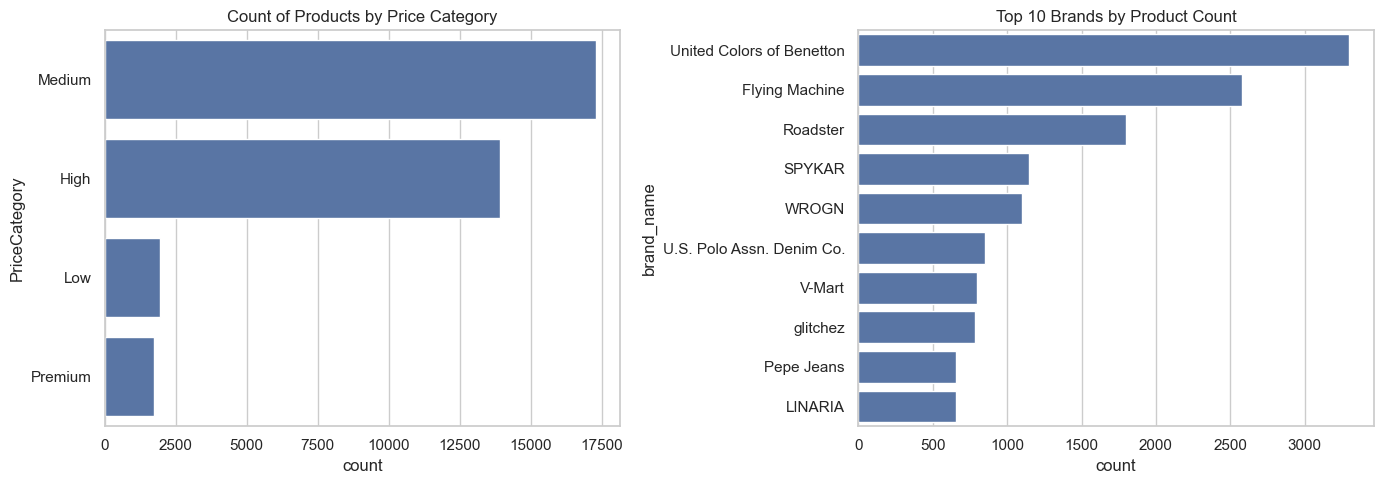

In [54]:
print(df['PriceCategory'].value_counts())
print(df['brand_name'].value_counts().head(10))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(y='PriceCategory', data=df, order=df['PriceCategory'].value_counts().index)
plt.title('Count of Products by Price Category')

plt.subplot(1, 2, 2)
top_brands = df['brand_name'].value_counts().head(10).index
sns.countplot(y='brand_name', data=df[df['brand_name'].isin(top_brands)], order=top_brands)
plt.title('Top 10 Brands by Product Count')

plt.tight_layout()
plt.show()

Insights -
1. The `price` and `MRP` distributions are heavily right-skewed. Most products are concentrated in the lower price range, while a small number of products extend to very high values, which creates a long right tail.
2. The mean price is higher than the median price, which confirms the presence of high-value outliers pulling the average upward.
3. `DiscountPercent` is concentrated mostly between about 40% and 65%, showing that medium-to-high discounting is the dominant pricing strategy across the catalog.
4. Product `ratings` are tightly clustered around 3.8 to 4.2, which indicates that most products receive moderately strong customer feedback and there is limited spread in rating behavior.
5. `number_of_ratings` is extremely right-skewed. Most products have relatively few ratings, while a small number of products have very large review counts, indicating uneven customer attention across the catalog.
6. The categorical distribution shows that the catalog is dominated by the `Medium` and `High` price segments, while `Low` and `Premium` categories contain far fewer products.
7. Brand frequency is also concentrated: a few brands such as United Colors of Benetton, Flying Machine, and Roadster contribute a large share of listings, suggesting strong assortment concentration.
8. Overall, the univariate analysis suggests the dataset is not normally distributed for most business variables, so median, IQR, and boxplots are often more reliable than mean alone for interpretation.

Scenario 13: Bivariate Analysis

Business Question: How do two variables interact with each other, and what business relationships can we observe?

Coverage:
- Price vs ratings
- Category vs Price
- Brand vs Ratings

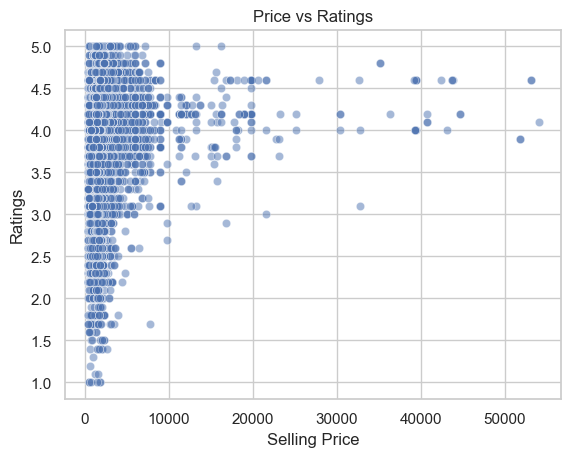

In [66]:
sns.scatterplot(x='price', y='ratings', data=df, alpha=0.5)
plt.title('Price vs Ratings')
plt.xlabel('Selling Price')
plt.ylabel('Ratings')
plt.show()

Insights - 
1. most products are concentrated at lower prices
2. ratings mostly fall between 3.0 and 4.8
3. there is no strong relationship between higher price and higher rating
4. a few expensive products exist, but their ratings still stay within a similar range

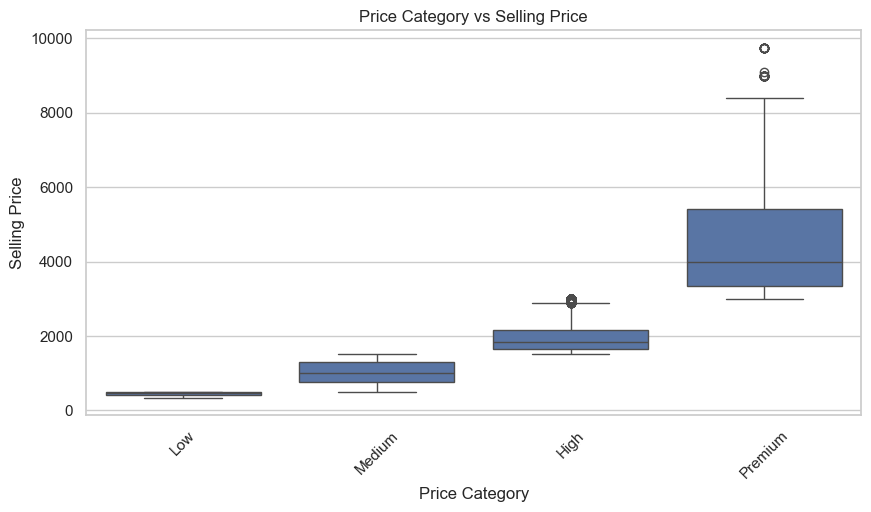

In [68]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='PriceCategory', y='price', data=df)
plt.xticks(rotation=45)
plt.title('Price Category vs Selling Price')
plt.xlabel('Price Category')
plt.ylabel('Selling Price')
plt.show()

Insights -
1. The boxplot shows a clear upward shift in selling price from Low to Premium categories, confirming that the price segmentation is meaningful.
2. Premium products have the highest median selling price and the widest spread, which suggests this segment contains a mix of moderately premium and very expensive items.
3. Low and Medium categories are more tightly distributed, indicating more consistent pricing within those segments.
4. A few very high-price outliers appear in the Premium category, which may represent luxury or exclusive products.
5. Overall, the chart suggests the business follows a tiered pricing strategy, with clear separation between customer affordability segments.

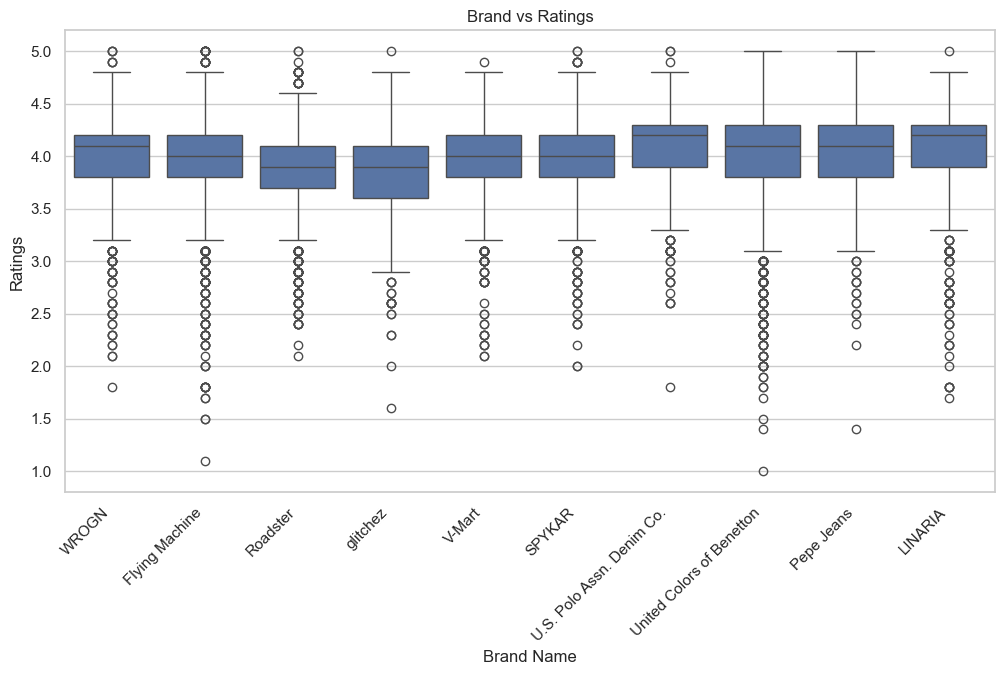

In [70]:
top_brands = df['brand_name'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='brand_name', y='ratings', data=df[df['brand_name'].isin(top_brands)])
plt.xticks(rotation=45, ha='right')
plt.title('Brand vs Ratings')
plt.xlabel('Brand Name')
plt.ylabel('Ratings')
plt.show()

Insights -
1. Most top brands have median ratings close to 4.0 to 4.2, which means customer satisfaction is fairly similar across the leading brands.
2. Some brands such as U.S. Polo Assn. Denim Co., LINARIA, and Pepe Jeans appear to have slightly higher central ratings, suggesting somewhat stronger and more consistent customer feedback.
3. Brands like Roadster and glitchez show slightly lower median ratings, but the gap is still not very large, so the brand differences are moderate rather than extreme.
4. The many low-rating outliers across almost all brands show that even strong brands can have a few poorly rated products.
5. Overall, this chart suggests brand reputation matters, but product-level quality consistency is still very important because ratings vary within each brand.

Scenario 14: Multivariate Analysis

Business Question: How do multiple variables interact together to reveal broader business patterns?

Coverage:
Example 1: Price + Category + Ratings

Example 2: Heatmap (Correlation Matrix)

Example 3: Category + Price Category + Discount

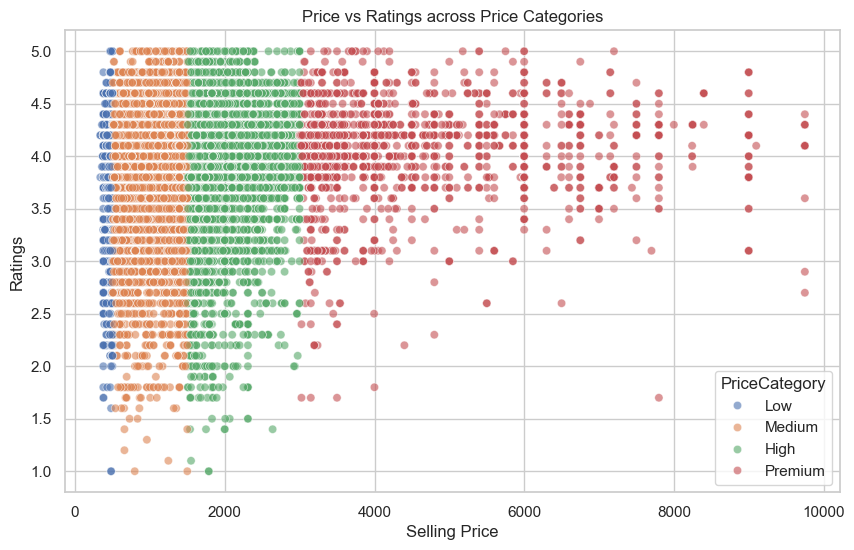

In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='ratings', hue='PriceCategory', data=df, alpha=0.6)
plt.title('Price vs Ratings across Price Categories')
plt.xlabel('Selling Price')
plt.ylabel('Ratings')
plt.show()

Insights - 
1. Low and Medium products are concentrated in lower price ranges with ratings spread mostly between 3.0 and 4.8
2. High and Premium products appear at larger price values and tend to cluster slightly higher in ratings
3. The relationship is still weak overall, but premium-priced items appear somewhat more stable in the upper rating range

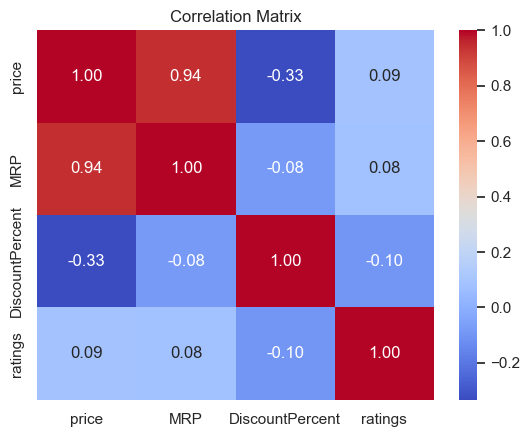

In [62]:
corr = df[['price', 'MRP', 'DiscountPercent', 'ratings']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Insights - 
1. price and MRP are strongly positively correlated at about 0.94
2. DiscountPercent has a moderate negative relationship with price
3. Ratings has very weak correlation with the other variables

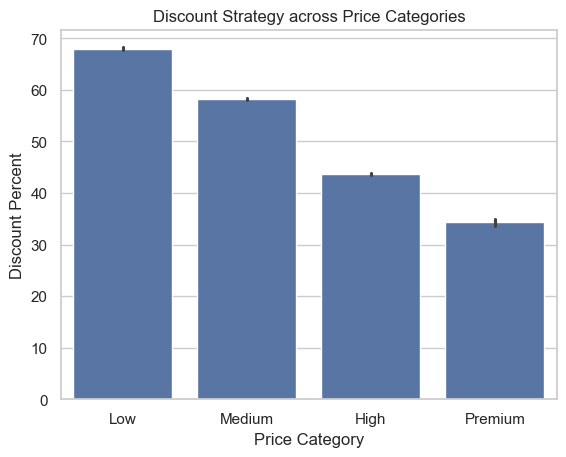

In [63]:
sns.barplot(x='PriceCategory', y='DiscountPercent', data=df)
plt.title('Discount Strategy across Price Categories')
plt.xlabel('Price Category')
plt.ylabel('Discount Percent')
plt.show()

Insights - 
1. Here are the insights for the Discount Strategy across Price Categories chart in analysis.ipynb:
2. The Low price category has the highest average discount, at about 68%.
This suggests low-priced products are being promoted very aggressively, likely to drive fast sales volume and attract price-sensitive customers.
3. The Medium category also has a high average discount, around 58%.
This means medium-priced products are also a major part of the promotional strategy and likely play a strong role in balancing revenue and conversions.
4. The High category has a lower average discount, around 44%.
This indicates that as product price increases, discounting becomes more controlled and margin protection becomes more important.
5. The Premium category has the lowest average discount, around 34%.
This suggests premium products are discounted more conservatively, likely to maintain perceived brand value and avoid over-discounting.
6. There is a clear downward trend in discount percentage as price category increases.
That means the business is not using one uniform pricing strategy. Instead, it is applying a tiered discount model based on product positioning.

### Final Business Recommendations

1. Focus assortment expansion on the `Medium` and `High` price categories.
These two segments contain the largest product volume and also contribute the strongest commercial potential, so they should remain the core focus for merchandising and inventory planning.

2. Use targeted discounting instead of applying the same discount strategy across all price bands.
The analysis shows that `Low` and `Medium` categories already rely on heavier discounts, while `Premium` products are discounted more conservatively. This suggests promotions should be tailored by segment to protect margins.

3. Strengthen high-performing brands with deeper category coverage.
Brands such as United Colors of Benetton, Flying Machine, and Roadster already dominate listings, so they offer strong opportunities for assortment optimization, cross-selling, and premium placement.

4. Improve visibility for smaller brands through selective promotions and differentiated positioning.
Since the catalog is concentrated among a few brands, smaller brands may need strategic discounts, better product positioning, or curated collections to compete more effectively.

5. Use ratings together with review volume when making brand or product decisions.
Average rating alone can be misleading, so products and brands should be evaluated using both customer satisfaction and review credibility.

6. Prioritize medium-discount strategies around the strongest performing range.
Most products are concentrated in the 40% to 70% discount band, especially around 50% to 65%, which suggests this is the most effective promotional range for driving engagement.

7. Monitor high-price outliers and premium products separately.
The dataset contains strong right-skewness in price and MRP, so premium and outlier products should be analyzed independently to avoid distorting decisions for the broader catalog.

8. Build future dashboards and reporting around segmented analysis.
Because price, discount, ratings, and review volume interact with each other, future reporting should be structured by price category, brand, and discount band rather than relying only on overall averages.